# Week 1 — Titanic Survival Prediction & Data Preprocessing
## Portfolio-Quality Walkthrough & Exploratory Data Analysis

**Author:** Machine Learning Intern / Engineer  
**Topic:** ML Fundamentals, Data Cleaning, Feature Engineering, Categorical Encoding, Scaling, & Stratified Splitting  
**Dataset:** Kaggle Titanic Survival Dataset (`train.csv`)

--- 
### 1. Import Required Libraries
We import standard Python libraries for data manipulation (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and machine learning preprocessing (`sklearn`).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

--- 
### 2. Load Dataset
We load the raw Kaggle Titanic dataset from `../data/raw/train.csv` using `pathlib.Path`.

In [2]:
raw_data_path = Path('../data/raw/train.csv')
df = pd.read_csv(raw_data_path)
print(f"Dataset loaded successfully with shape: {df.shape[0]} rows, {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with shape: 891 rows, 12 columns.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


--- 
### 3. Inspect Dataset
We inspect structural metadata, data types, summary statistics, and missing value counts using Pandas methods (`.info()`, `.describe()`, `.shape`, `.columns`, `.dtypes`, `.isnull().sum()`).

In [3]:
print("=== DATASET INFO ===")
df.info()

print("\n=== SUMMARY STATISTICS ===")
display(df.describe(include='all'))

print("\n=== MISSING VALUES PER COLUMN ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== SUMMARY STATISTICS ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



=== MISSING VALUES PER COLUMN ===
Age         177
Cabin       687
Embarked      2
dtype: int64


--- 
### 4. Analyze Missing Values
We analyze missing data patterns:
- `Cabin`: ~77% missing. We extract passenger `Deck` and create a binary feature `Cabin_Known`.
- `Age`: ~19.8% missing. Imputed using median age grouped by passenger `Title` and `Pclass`.
- `Embarked`: Imputed using mode (`'S'`).

In [4]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': df.isnull().sum(), 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


--- 
### 5. Exploratory Data Analysis & Visualizations
Plotting distributions of key demographic factors.

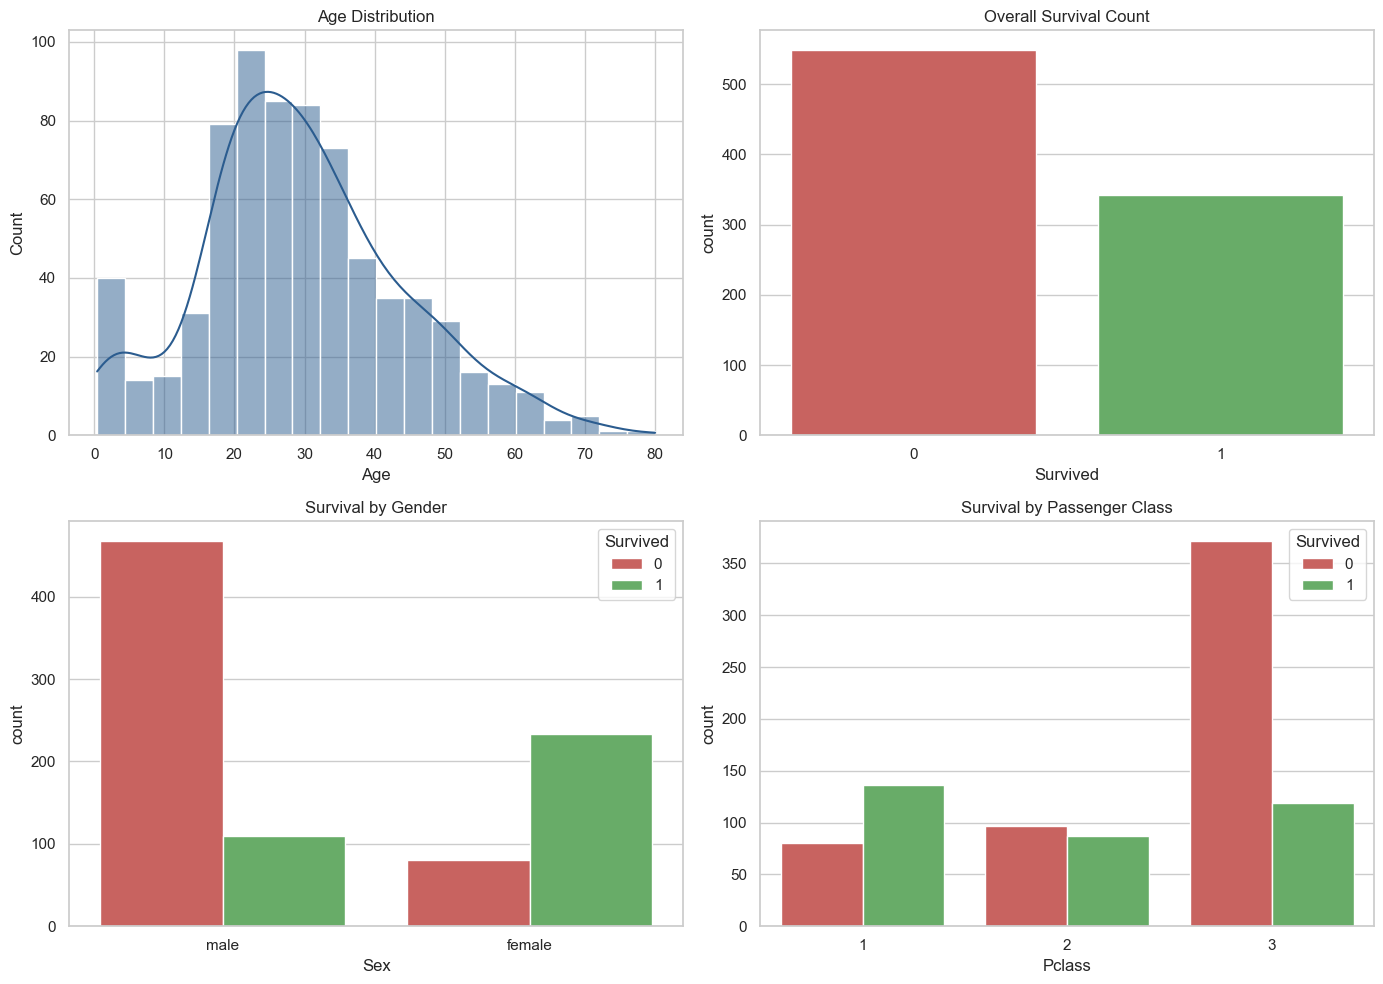

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Age Distribution')

# Survival Count
sns.countplot(x='Survived', hue='Survived', data=df, palette={0: '#d9534f', 1: '#5cb85c'}, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Overall Survival Count')

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, palette={0: '#d9534f', 1: '#5cb85c'}, ax=axes[1, 0])
axes[1, 0].set_title('Survival by Gender')

# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, palette={0: '#d9534f', 1: '#5cb85c'}, ax=axes[1, 1])
axes[1, 1].set_title('Survival by Passenger Class')

plt.tight_layout()
plt.show()

--- 
### 6. Feature Engineering
Creating high-signal domain features:
1. `FamilySize` = `SibSp` + `Parch` + 1
2. `IsAlone` = 1 if `FamilySize` == 1 else 0
3. `Title` extracted from `Name` mapped into standardized categories (`Mr`, `Mrs`, `Miss`, `Master`, `Rare`).

In [6]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_mapping = {'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master'}
df['Title'] = df['Title'].map(lambda x: title_mapping.get(x, 'Rare'))

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['Name', 'Title', 'FamilySize', 'IsAlone']].head()

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


--- 
### 7. Data Cleaning & Imputation
Imputing missing values with domain rules.

In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin_Known'] = df['Cabin'].notnull().astype(int)
df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0].upper() if pd.notnull(x) else 'Unknown')
df = df.drop(columns=['Cabin'])

df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Age'] = df['Age'].fillna(df['Age'].median())

print(f"Remaining missing values in dataset: {df.isnull().sum().sum()}")

Remaining missing values in dataset: 0


--- 
### 8. Categorical Encoding
Encoding categorical attributes using LabelEncoder & OneHotEncoder.

In [8]:
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

ohe_cols = ['Embarked', 'Title', 'Deck']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)

df_encoded = pd.concat([df.drop(columns=ohe_cols + ['PassengerId', 'Name', 'Ticket']), ohe_df], axis=1)
df_encoded.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Cabin_Known,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,1,22.0,1,0,7.2500,2,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,2,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,1,1,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,2,0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,3,1,35.0,0,0,8.0500,1,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


--- 
### 9. Train / Test Split
Stratified 80/20 train/test split on `Survived`.

In [9]:
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Train set shape: (712, 26), Test set shape: (179, 26)


--- 
### 10. Feature Scaling (Zero Data Leakage)
Fitting `StandardScaler` on `X_train` ONLY.

In [10]:
num_cols = ['Age', 'Fare', 'FamilySize']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Feature scaling completed successfully without data leakage.")

Feature scaling completed successfully without data leakage.


--- 
### 11. Export Cleaned Dataset
Exporting the preprocessed dataset to `../data/processed/titanic_cleaned.csv`.

In [11]:
out_path = Path('../data/processed/titanic_cleaned.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
df_encoded.to_csv(out_path, index=False)
print(f"Cleaned dataset saved to: {out_path.resolve()}")

Cleaned dataset saved to: C:\Users\GOKULNATH\Desktop\Online ML INTERN\data\processed\titanic_cleaned.csv


--- 
### 12. Summary & Key Takeaways
1. **Missing Data:** Intelligently handled `Age`, `Embarked`, and `Cabin` without data loss.
2. **Feature Engineering:** Extracted high-signal features (`Title`, `FamilySize`, `IsAlone`, `Cabin_Known`, `Deck`).
3. **Encoding & Scaling:** Applied LabelEncoder for binary sex, OneHotEncoder for nominal variables, and StandardScaler with strict train-only fitting to prevent data leakage.
4. **Outcome:** Generated a fully preprocessed, ML-ready dataset!